In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
cleaned_data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/Demographic/demographic.csv')

In [3]:
X = cleaned_data.drop(columns=['Delirium at any time during hospitalization'], inplace=False)
y = cleaned_data['Delirium at any time during hospitalization']

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
xgb_model = XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:40:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


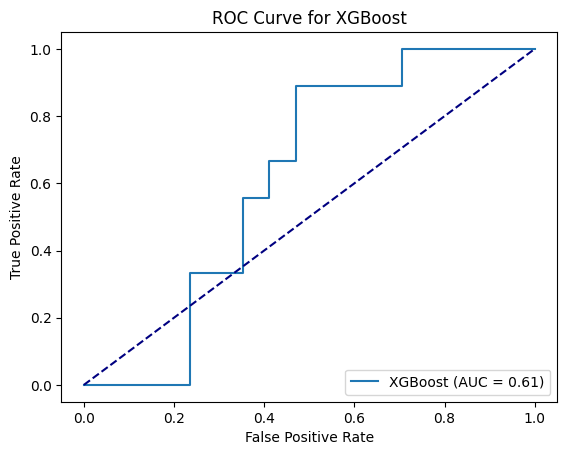

ROC AUC Score: 0.61
Accuracy: 0.54
Confusion Matrix:
[[13  4]
 [ 8  1]]


In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

# Step 8: Output Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:40:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


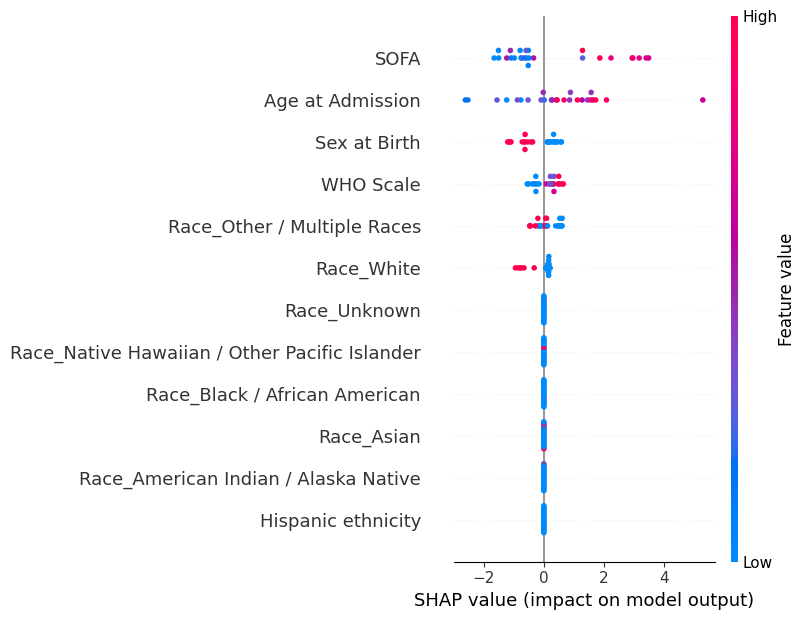

In [7]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
xgb_model.fit(X_train_scaled, y_train)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(xgb_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)

In [8]:
X_fs = cleaned_data[['WHO Scale', 'SOFA', 'Age at Admission']]
y_fs = cleaned_data['Delirium at any time during hospitalization']

In [9]:
X_trainFS, X_testFS, y_trainFS, y_testFS = train_test_split(X_fs, y_fs, test_size=0.2, random_state=42)

xgb_modelFS = XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
xgb_modelFS.fit(X_trainFS, y_trainFS)

y_predFS_proba = xgb_modelFS.predict_proba(X_testFS)[:, 1]
y_pred = xgb_modelFS.predict(X_testFS)

roc_auc = roc_auc_score(y_testFS, y_predFS_proba)

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:40:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


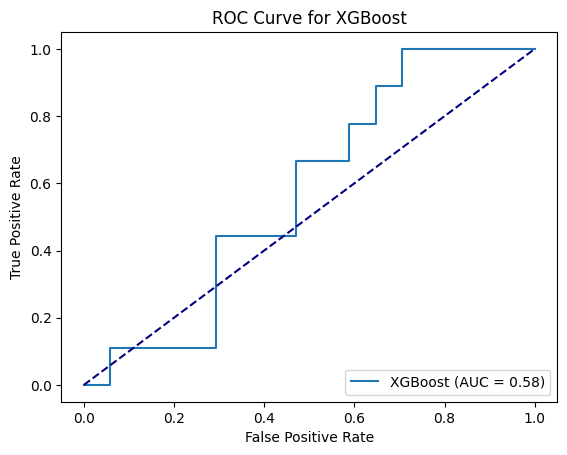

ROC AUC Score: 0.58
Accuracy: 0.54
Confusion Matrix:
[[13  4]
 [ 8  1]]


In [10]:
fpr, tpr, thresholds = roc_curve(y_testFS, y_predFS_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

# Step 8: Output Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:40:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


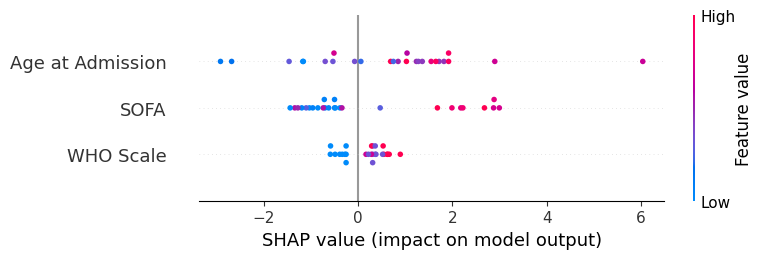

In [11]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_trainFS), columns=X_trainFS.columns, index=X_trainFS.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_testFS), columns=X_testFS.columns, index=X_testFS.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
xgb_model.fit(X_train_scaled, y_trainFS)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(xgb_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)